In [40]:
from torch.utils.data import Dataset, Subset
from torch.utils.data import random_split, DataLoader, RandomSampler
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import time

train_dataset = datasets.MNIST(root='data',
                               train=True,
                               transform=transforms.ToTensor(),
                               download=True)

train_loader = DataLoader(dataset=train_dataset,
                          batch_size=6000,
                          shuffle=True)


# check the output
start = time.time()
for i, batch in enumerate(train_loader):
    if i == 50:
        break
end = time.time() 
print(end - start)   

1.930422067642212


0.18860793113708496


In [1]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from data_loader import load_data
from feedforward_nn import FeedforwardNN
from train_test_utils import train_and_test
from experiment_manager import get_input_dim, get_output_dim
from mask_generation import generate_random_sparse_tensor, generate_random_directed_adjacency
# Load the data
train_data, test_data = load_data(dataset='mnist')

mask = generate_random_directed_adjacency(784, 'sf','sf', 2.4, 1)
print(mask.dtype)
# Create dataloaders
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128)

# Create the model
input_dim = get_input_dim(train_data)
output_dim = get_output_dim(train_data)
model = FeedforwardNN(input_dim, output_dim=output_dim,mask=mask, problem_type='classification')

# Create the optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Train and test the model
training_errors, test_errors = train_and_test(model, train_loader, test_loader, optimizer, learning_rule='bp', problem_type='classification', epochs=10)

# Print the results
print("Training errors:", training_errors)
print("Test errors:", test_errors)

/opt/homebrew/Caskroom/miniforge/base/envs/myenv/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: dlopen(/opt/homebrew/Caskroom/miniforge/base/envs/myenv/lib/python3.10/site-packages/torchvision/image.so, 6): Library not loaded: @rpath/libjpeg.8.dylib
  Referenced from: /opt/homebrew/Caskroom/miniforge/base/envs/myenv/lib/python3.10/site-packages/torchvision/image.so
  Reason: image not found
  warn(f"Failed to load image Python extension: {e}")


torch.float32


KeyboardInterrupt: 

In [16]:
from experiment_manager import run_simulation_ff

In [18]:
run_simulation_ff(train_data, test_data, epochs = 10)

in_dim = 784, out_dim = 10
Training with {'learning_rule': 'fa', 'lr': 0.03746026648354778, 'batch_size': 128, 'n_hidden': 1, 'trial': 0}
Training with {'learning_rule': 'fa', 'lr': 0.03746026648354778, 'batch_size': 128, 'n_hidden': 2, 'trial': 0}
Training with {'learning_rule': 'fa', 'lr': 0.09507192349792752, 'batch_size': 128, 'n_hidden': 1, 'trial': 0}
Training with {'learning_rule': 'fa', 'lr': 0.09507192349792752, 'batch_size': 128, 'n_hidden': 2, 'trial': 0}


KeyboardInterrupt: 

In [7]:
from data_loader import load_data
from mask_generation import generate_random_directed_adjacency, generate_random_sparse_tensor

#D = 100
# generate synthetic classification dataset
train_data, test_data = load_data(dataset='mnist')


In [1]:
from experiment_manager import get_input_dim, get_output_dim


In [9]:
get_input_dim(train_data)

784

In [4]:
run_simulation_ff(train_data, test_data, epochs=1)

Training with {'learning_rule': 'fa', 'lr': 0.03746026648354778, 'batch_size': 128, 'n_hidden': 1, 'trial': 0}
Training with {'learning_rule': 'fa', 'lr': 0.03746026648354778, 'batch_size': 128, 'n_hidden': 2, 'trial': 0}
Training with {'learning_rule': 'fa', 'lr': 0.09507192349792752, 'batch_size': 128, 'n_hidden': 1, 'trial': 0}
Training with {'learning_rule': 'fa', 'lr': 0.09507192349792752, 'batch_size': 128, 'n_hidden': 2, 'trial': 0}
Training with {'learning_rule': 'fa', 'lr': 0.0732020742417224, 'batch_size': 128, 'n_hidden': 1, 'trial': 0}
Training with {'learning_rule': 'fa', 'lr': 0.0732020742417224, 'batch_size': 128, 'n_hidden': 2, 'trial': 0}
Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/opt/homebrew/Caskroom/miniforge/base/envs/myenv/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 3505, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/tr/_q_8102j4vs9md0z9mn20kw00000gn/T/ipykernel_31810/922692633.py", line 1, in <module>
    run_simulation_ff(train_data, test_data, epochs=1)
  File "/Users/razifachareldeen/Documents/Research/Exploratory-Adaptation/ScaleFreeFF/experiment_manager.py", line 81, in run_simulation_ff
  File "/Users/razifachareldeen/Documents/Research/Exploratory-Adaptation/ScaleFreeFF/train_test_utils.py", line 46, in train_and_test
    train(model, train_loader, criterion, optimizer, learning_rule)
  File "/Users/razifachareldeen/Documents/Research/Exploratory-Adaptation/ScaleFreeFF/train_test_utils.py", line 14, in train
    loss.backward()
  File "/opt/homebrew/Caskroom/miniforge/base/envs/myenv/lib/python3.10/site-packages/torch/_tensor.py", line 488, 

In [7]:
x, y = train_data[0]
y

tensor(0)

In [2]:
D = 784
# generate masks
in_dist, out_dist = 'sf', 'binom'
gamma, a = 2.4,1
mean_k, beta = 3.5, 3.5

mask_1 = generate_random_directed_adjacency(D, in_dist, out_dist, gamma=gamma, a=a, beta=beta, mean_k=mean_k)
mask_2 = mask_1.t()#generate_random_directed_adjacency(D, out_dist, in_dist, gamma=gamma, a=a, beta=beta, mean_k=mean_k)
mask_3 = generate_random_sparse_tensor(D, mask_1.sum())
mask_4 = generate_random_directed_adjacency(D, 'sf', 'sf', gamma=gamma, a=a, beta=beta, mean_k=mean_k)

In [ ]:
import

In [2]:
D = 784
# generate masks
in_dist, out_dist = 'sf', 'binom'
gamma, a = 2.4,1
mean_k, beta = 3.5, 3.5

def generate_random_directed_adjacency(input_size, output_size, in_dist, out_dist, gamma=None, a=None, beta=None, mean_k=None):
    g = gt.random_graph(input_size + output_size,
                        lambda _: (degree_rv(dist=in_dist, gamma=gamma, a=a, beta=beta, mean_k=mean_k, N=input_size),
                                   degree_rv(dist=out_dist, gamma=gamma, a=a, beta=beta, mean_k=mean_k, N=output_size)),
                        directed=True)

    # Convert the graph to an adjacency matrix
    adjacency_matrix = gt.adjacency(g).toarray().astype(np.int16)
    
    # Extract the submatrix corresponding to input-output layer connections
    adjacency_matrix_sub = adjacency_matrix[:input_size, input_size:]

    return torch.tensor(adjacency_matrix_sub, dtype=torch.float)

In [34]:
np.random.zipf??

In [ ]:
mask = 

In [21]:
import torch
import numpy as np
import networkx as nx

def generate_ba_scale_free(size, m):
    G = nx.barabasi_albert_graph(size, m)
    degree_sequence = [d for n, d in G.degree()]
    return degree_sequence

def generate_connection_matrix(input_size, output_size, input_degree, output_degree):
    assert len(input_degree) == input_size, "input_degree length must match input_size"
    assert len(output_degree) == output_size, "output_degree length must match output_size"

    connection_matrix = np.zeros((input_size, output_size))

    for i, in_deg in enumerate(input_degree):
        in_indices = np.random.choice(output_size, size=in_deg, replace=False)
        connection_matrix[i, in_indices] = 1

    for j, out_deg in enumerate(output_degree):
        out_indices = np.random.choice(input_size, size=out_deg, replace=False)
        connection_matrix[out_indices, j] = 1

    return torch.tensor(connection_matrix, dtype=torch.float)




In [22]:
input_size = 50
output_size = 100
m = 3

input_degree = generate_ba_scale_free(input_size, m)
output_degree = generate_ba_scale_free(output_size, m)

connection_matrix = generate_connection_matrix(input_size, output_size, input_degree, output_degree)


(array([ 5.,  7., 11.,  7.,  6.,  4.,  5.,  1.,  3.,  1.]),
 array([10.        , 11.80000019, 13.60000038, 15.39999962, 17.20000076,
        19.        , 20.79999924, 22.60000038, 24.39999962, 26.20000076,
        28.        ]),
 <BarContainer object of 10 artists>)

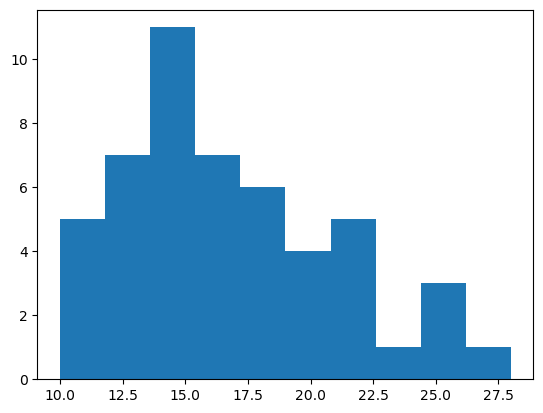

In [28]:
plt.hist(connection_matrix.sum(1))

In [8]:
import numpy as np
import torch
import graph_tool.all as gt
from scipy.stats import genpareto
from scipy.sparse import coo_matrix



In [9]:
in_dist, out_dist = 'sf', 'binom'
gamma, a = 2.4,1
mean_k, beta = 3.5, 3.5
import graph_tool.all as gt
def degree_rv(dist, gamma=None, a=None, beta=None, mean_k=None, N=None):
    if dist == 'sf':
        assert gamma is not None, "gamma must be specified for SF distribution"
        assert a is not None, "mu must be specified for SF distribution"
        return genpareto.rvs(c=1/(gamma-1), scale=a/(gamma-1), loc=a)
    elif dist == 'binom':
        assert mean_k is not None, "mean_k must be specified for binom distribution"
        assert N is not None, "N must be specified for binom distribution"
        return np.random.binomial(n=N, p=mean_k/N)
    elif dist == 'exp':
        assert beta is not None, "N must be specified for binom distribution"
        return np.random.exponential(scale=beta)


In [29]:
mask = generate_random_directed_adjacency(100,50,in_dist, out_dist, gamma, a, beta, mean_k)

(array([ 3., 13.,  0., 16.,  0., 10.,  3.,  0.,  4.,  1.]),
 array([0.        , 0.60000002, 1.20000005, 1.79999995, 2.4000001 ,
        3.        , 3.5999999 , 4.19999981, 4.80000019, 5.4000001 ,
        6.        ]),
 <BarContainer object of 10 artists>)

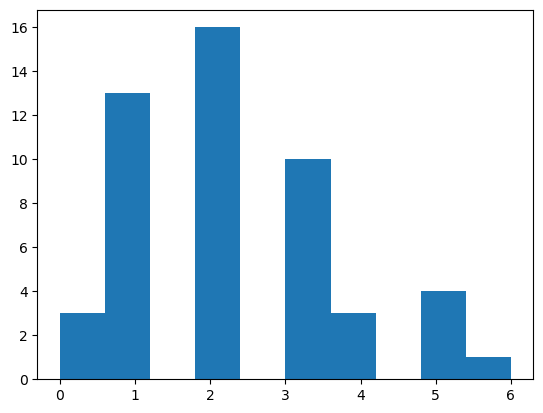

In [33]:
plt.hist(mask.sum(0))

(array([776.,   5.,   0.,   1.,   0.,   0.,   0.,   1.,   0.,   1.]),
 array([  0. ,  10.5,  21. ,  31.5,  42. ,  52.5,  63. ,  73.5,  84. ,
         94.5, 105. ]),
 <BarContainer object of 10 artists>)

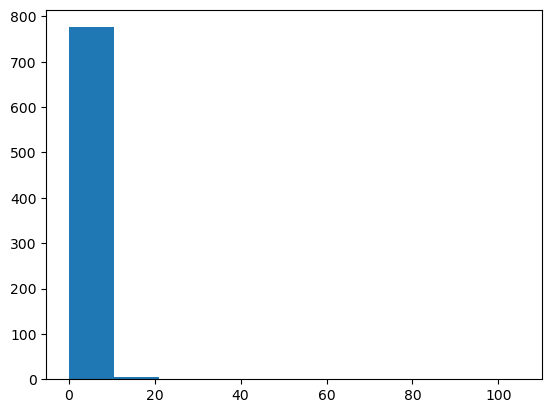

In [20]:
import matplotlib.pyplot as plt
plt.hist(mask.sum(1))

In [22]:
from experiment_manager import run_simulation_ff_multi_masks, run_simulation_ff
masks = [None]
res = run_simulation_ff_multi_masks(train_data=train_data, test_data=test_data, masks=masks, trials=1, epochs=10)

Running experiments for mask 1


AttributeError: 'TensorDataset' object has no attribute 'classes'

In [15]:
t

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [7]:
masks_names = ['sf_binom','binom_sf','uniform','sf_sf']

In [11]:
import matplotlib.pyplot as plt
import numpy as np

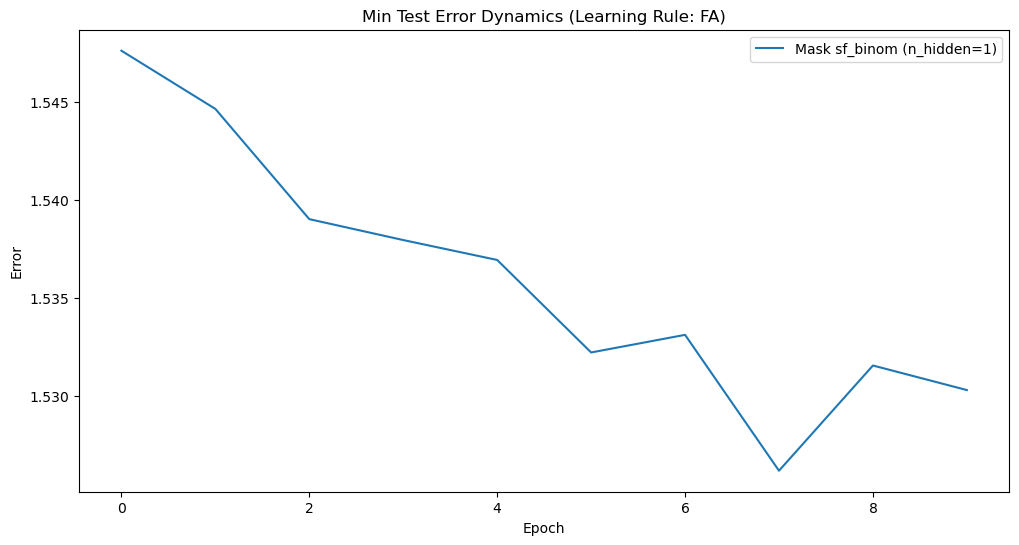

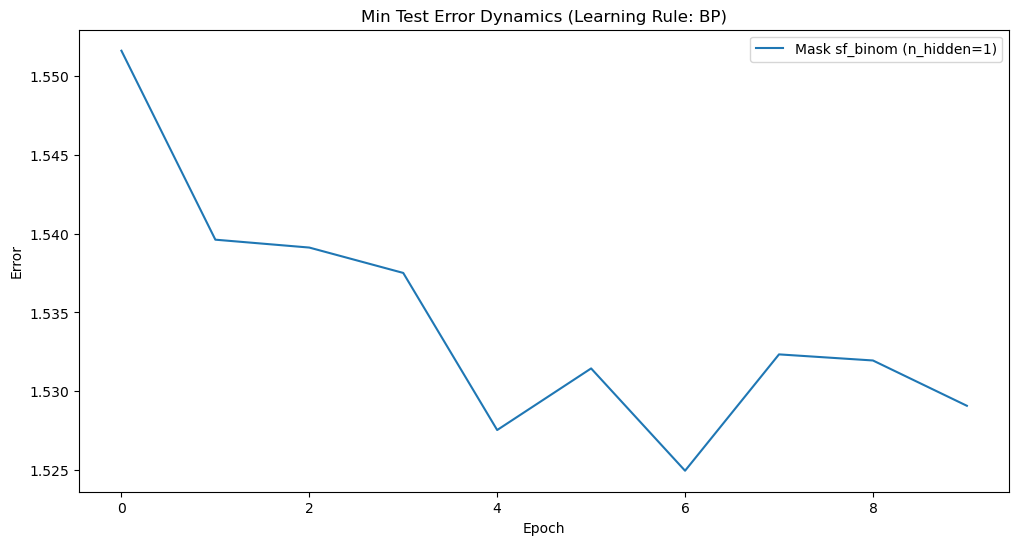

In [13]:
#from plot_utils import plot_error_multi_masks2
plot_error_multi_masks2(res, agg_method='min',masks_names=masks_names, by_learning_rule=True, n_hidden_value=1, plot_error_type='test')

In [5]:
def plot_error_multi_masks2(mask_results, masks_names=None, plot_error_type='training', agg_method='mean', by_learning_rule=False, learning_rule=None, by_n_hidden=False, n_hidden_value=None):
    assert plot_error_type in ['training', 'test'], "plot_error_type must be either 'training' or 'test'."
    assert agg_method in ['mean', 'min', 'median'], "agg_method must be either 'mean', 'min', or 'median'."
    assert not (by_learning_rule and learning_rule), "Cannot specify both by_learning_rule and learning_rule parameters."

    n_masks = len(mask_results)
    if masks_names is None:
        masks_names = ['Mask ' + str(i+1) for i in range(n_masks)]
    learning_rules = ['fa', 'bp']
    
    if by_learning_rule:
        n_plots = len(learning_rules)
    else:
        n_plots = 1

    for plot_idx in range(n_plots):
        if by_learning_rule:
            learning_rule = learning_rules[plot_idx]
            plt.figure(figsize=(12, 6))
        
        for mask_idx in range(n_masks):
            mask_result = mask_results[mask_idx]

            if plot_error_type == 'training':
                errors = mask_result['training_errors']
            else:
                errors = mask_result['test_errors']

            if by_learning_rule:
                filtered_errors = {key: error for key, error in errors.items() if learning_rule in key}
            elif learning_rule:
                filtered_errors = {learning_rule + '_' + plot_error_type: errors[learning_rule + '_' + plot_error_type]}
            else:
                filtered_errors = errors

            unique_n_hidden = list(set([int(key.split('_n_hidden')[-1].split('_')[0]) for key in filtered_errors.keys()]))

            for n_hidden in unique_n_hidden:
                if by_n_hidden or (n_hidden_value is not None and n_hidden == n_hidden_value):
                    n_hidden_errors = {key: error for key, error in filtered_errors.items() if f"n_hidden{n_hidden}" in key}
                else:
                    continue

                if agg_method == 'mean':
                    agg_func = np.mean
                elif agg_method == 'min':
                    agg_func = np.min
                else:
                    agg_func = np.median

                agg_error = agg_func(list(n_hidden_errors.values()), axis=0)
                plt.plot(agg_error, label=f"Mask {masks_names[mask_idx]} (n_hidden={n_hidden})")

        plt.xlabel('Epoch')
        plt.ylabel('Error')
        
        if by_learning_rule:
            plt.title(f'{agg_method.capitalize()} {plot_error_type.capitalize()} Error Dynamics (Learning Rule: {learning_rule.upper()})')
        else:
            plt.title(f'{agg_method.capitalize()} {plot_error_type.capitalize()} Error Dynamics')

        plt.legend()
        plt.show()
